# Week 3 Project: Python and Data Wrangling

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [11]:
df = pd.read_csv(r"C:\Users\amans\Downloads\data (3).csv")
df.head()

,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [6]:
print("Dataset shape:", df.shape)


Dataset shape: (32, 5)


In [7]:
print("Column names:", list(df.columns))

Column names: ['Duration', 'Date', 'Pulse', 'Maxpulse', 'Calories']


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32 entries, 0 to 31
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Duration  32 non-null     int64  
 1   Date      31 non-null     object 
 2   Pulse     32 non-null     int64  
 3   Maxpulse  32 non-null     int64  
 4   Calories  30 non-null     float64
dtypes: float64(1), int64(3), object(1)
memory usage: 1.4+ KB


In [13]:
display(df.head())


,Duration,Date,Pulse,Maxpulse,Calories
0,60,'2020/12/01',110,130,409.1
1,60,'2020/12/02',117,145,479.0
2,60,'2020/12/03',103,135,340.0
3,45,'2020/12/04',109,175,282.4
4,45,'2020/12/05',117,148,406.0


In [14]:
display(df.tail())

,Duration,Date,Pulse,Maxpulse,Calories
27,60,'2020/12/27',92,118,241.0
28,60,'2020/12/28',103,132,NaN
29,60,'2020/12/29',100,132,280.0
30,60,'2020/12/30',102,129,380.3
31,60,'2020/12/31',92,115,243.0


In [15]:
df.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Duration,32.0,NaN,NaN,NaN,68.4375,70.039591,30.0,60.0,60.0,60.0,450.0
Date,31,30,'2020/12/12',2,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Pulse,32.0,NaN,NaN,NaN,103.5,7.832933,90.0,100.0,102.5,106.5,130.0
Maxpulse,32.0,NaN,NaN,NaN,128.5,12.998759,101.0,120.0,127.5,132.25,175.0
Calories,30.0,NaN,NaN,NaN,304.68,66.003779,195.1,250.7,291.2,343.975,479.0


In [16]:
initial_quality = pd.DataFrame({
    "data_type": df.dtypes.astype(str),
    "missing_count": df.isna().sum(),
    "missing_percent": (df.isna().mean() * 100).round(2),
    "unique_count": df.nunique(dropna=True)
})
initial_quality

,data_type,missing_count,missing_percent,unique_count
Duration,int64,0,0.00,4
Date,object,1,3.12,30
Pulse,int64,0,0.00,15
Maxpulse,int64,0,0.00,24
Calories,float64,2,6.25,26


In [17]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 1


In [18]:
print("Raw date values:", df["Date"].dropna().head(10).tolist())

Raw date values: ["'2020/12/01'", "'2020/12/02'", "'2020/12/03'", "'2020/12/04'", "'2020/12/05'", "'2020/12/06'", "'2020/12/07'", "'2020/12/08'", "'2020/12/09'", "'2020/12/10'"]


In [19]:
clean_df = df.copy()

clean_df.columns = (
    clean_df.columns
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

clean_df.columns.tolist()

['duration', 'date', 'pulse', 'maxpulse', 'calories']

In [20]:
clean_df["date"] = (
    clean_df["date"]
    .astype("string")
    .str.strip()
    .str.replace("'", "", regex=False)
)

clean_df["date"] = pd.to_datetime(
    clean_df["date"],
    format="mixed",
    errors="coerce"
)

numeric_columns = ["duration", "pulse", "maxpulse", "calories"]

for column in numeric_columns:
    clean_df[column] = pd.to_numeric(clean_df[column], errors="coerce")

clean_df.dtypes

duration             int64
date        datetime64[ns]
pulse                int64
maxpulse             int64
calories           float64
dtype: object

In [21]:
quality_checks = pd.Series({
    "missing_dates": clean_df["date"].isna().sum(),
    "missing_calories": clean_df["calories"].isna().sum(),
    "duplicate_rows": clean_df.duplicated().sum(),
    "duration_above_180_minutes": (clean_df["duration"] > 180).sum(),
    "pulse_above_maxpulse": (clean_df["pulse"] > clean_df["maxpulse"]).sum()
})
quality_checks

missing_dates                 1
missing_calories              2
duplicate_rows                1
duration_above_180_minutes    1
pulse_above_maxpulse          1
dtype: int64

In [22]:
print("Potential extreme-duration records")
display(clean_df.loc[clean_df["duration"] > 180])

Potential extreme-duration records


,duration,date,pulse,maxpulse,calories
7,450,2020-12-08,104,134,253.3


In [23]:
print("Potentially invalid pulse records")
display(clean_df.loc[clean_df["pulse"] > clean_df["maxpulse"]])

Potentially invalid pulse records


,duration,date,pulse,maxpulse,calories
23,60,2020-12-23,130,101,300.0


In [24]:
# Remove exact duplicate rows.
clean_df = clean_df.drop_duplicates().copy()

# Replace extreme durations with the median of non-extreme durations.
valid_duration_median = clean_df.loc[
    clean_df["duration"] <= 180, "duration"
].median()

clean_df.loc[
    clean_df["duration"] > 180, "duration"
] = valid_duration_median

# Drop records without a date.
clean_df = clean_df.dropna(subset=["date"]).copy()

# Remove logically impossible pulse records.
clean_df = clean_df.loc[
    clean_df["pulse"] <= clean_df["maxpulse"]
].copy()

clean_df = clean_df.sort_values("date").reset_index(drop=True)
clean_df.head()

,duration,date,pulse,maxpulse,calories
0,60,2020-12-01,110,130,409.1
1,60,2020-12-02,117,145,479.0
2,60,2020-12-03,103,135,340.0
3,45,2020-12-04,109,175,282.4
4,45,2020-12-05,117,148,406.0


In [25]:
missing_before = clean_df["calories"].isna().sum()

duration_medians = clean_df.groupby("duration")["calories"].transform("median")
clean_df["calories"] = clean_df["calories"].fillna(duration_medians)
clean_df["calories"] = clean_df["calories"].fillna(clean_df["calories"].median())

missing_after = clean_df["calories"].isna().sum()
print(f"Missing calories before cleaning: {missing_before}")
print(f"Missing calories after cleaning: {missing_after}")

Missing calories before cleaning: 2
Missing calories after cleaning: 0


In [26]:
final_quality = pd.DataFrame({
    "data_type": clean_df.dtypes.astype(str),
    "missing_count": clean_df.isna().sum(),
    "missing_percent": (clean_df.isna().mean() * 100).round(2),
    "unique_count": clean_df.nunique(dropna=True)
})
final_quality

,data_type,missing_count,missing_percent,unique_count
duration,int64,0,0.0,3
date,datetime64[ns],0,0.0,29
pulse,int64,0,0.0,14
maxpulse,int64,0,0.0,22
calories,float64,0,0.0,27


In [27]:
verification = pd.Series({
    "original_rows": len(df),
    "cleaned_rows": len(clean_df),
    "rows_removed": len(df) - len(clean_df),
    "remaining_missing_values": clean_df.isna().sum().sum(),
    "remaining_duplicates": clean_df.duplicated().sum(),
    "durations_above_180": (clean_df["duration"] > 180).sum(),
    "invalid_pulse_records": (clean_df["pulse"] > clean_df["maxpulse"]).sum()
})
verification

original_rows               32
cleaned_rows                29
rows_removed                 3
remaining_missing_values     0
remaining_duplicates         0
durations_above_180          0
invalid_pulse_records        0
dtype: int64

In [28]:
clean_df["day_name"] = clean_df["date"].dt.day_name()
clean_df["day_number"] = clean_df["date"].dt.dayofweek
clean_df["calories_per_minute"] = clean_df["calories"] / clean_df["duration"]
clean_df["pulse_gap"] = clean_df["maxpulse"] - clean_df["pulse"]

clean_df["intensity"] = pd.cut(
    clean_df["pulse"],
    bins=[0, 99, 109, np.inf],
    labels=["Low", "Moderate", "High"]
)

clean_df.head()

,duration,date,pulse,maxpulse,calories,day_name,day_number,calories_per_minute,pulse_gap,intensity
0,60,2020-12-01,110,130,409.1,Tuesday,1,6.818333,20,High
1,60,2020-12-02,117,145,479.0,Wednesday,2,7.983333,28,High
2,60,2020-12-03,103,135,340.0,Thursday,3,5.666667,32,Moderate
3,45,2020-12-04,109,175,282.4,Friday,4,6.275556,66,Moderate
4,45,2020-12-05,117,148,406.0,Saturday,5,9.022222,31,High


In [29]:
# Workouts lasting at least 60 minutes.
long_workouts = clean_df[clean_df["duration"] >= 60]
long_workouts[["date", "duration", "pulse", "calories"]].head()

,date,duration,pulse,calories
0,2020-12-01,60,110,409.1
1,2020-12-02,60,117,479.0
2,2020-12-03,60,103,340.0
5,2020-12-06,60,102,300.0
6,2020-12-07,60,110,374.0


In [30]:
# Workouts that burned at least 300 calories.
high_calorie_workouts = clean_df[clean_df["calories"] >= 300]
high_calorie_workouts[["date", "duration", "pulse", "calories"]]

,date,duration,pulse,calories
0,2020-12-01,60,110,409.1
1,2020-12-02,60,117,479.0
2,2020-12-03,60,103,340.0
4,2020-12-05,45,117,406.0
5,2020-12-06,60,102,300.0
6,2020-12-07,60,110,374.0
10,2020-12-11,60,103,329.3
12,2020-12-13,60,106,345.3
13,2020-12-14,60,104,379.3
16,2020-12-17,60,100,300.0


In [31]:
# Workouts lasting at least 60 minutes and burning at least 300 calories.
selected_workouts = clean_df[
    (clean_df["duration"] >= 60) &
    (clean_df["calories"] >= 300)
]
selected_workouts[["date", "duration", "pulse", "calories", "intensity"]]

,date,duration,pulse,calories,intensity
0,2020-12-01,60,110,409.1,High
1,2020-12-02,60,117,479.0,High
2,2020-12-03,60,103,340.0,Moderate
5,2020-12-06,60,102,300.0,Moderate
6,2020-12-07,60,110,374.0,High
10,2020-12-11,60,103,329.3,Moderate
12,2020-12-13,60,106,345.3,Moderate
13,2020-12-14,60,104,379.3,Moderate
16,2020-12-17,60,100,300.0,Moderate
18,2020-12-19,60,103,323.0,Moderate


In [32]:
top_calorie_workouts = clean_df.sort_values(
    "calories", ascending=False
).head(10)

top_calorie_workouts[
    ["date", "duration", "pulse", "maxpulse", "calories", "intensity"]
]

,date,duration,pulse,maxpulse,calories,intensity
1,2020-12-02,60,117,145,479.0,High
0,2020-12-01,60,110,130,409.1,High
4,2020-12-05,45,117,148,406.0,High
27,2020-12-30,60,102,129,380.3,Moderate
13,2020-12-14,60,104,132,379.3,Moderate
6,2020-12-07,60,110,136,374.0,High
20,2020-12-21,60,108,131,364.2,Moderate
12,2020-12-13,60,106,128,345.3,Moderate
2,2020-12-03,60,103,135,340.0,Moderate
22,2020-12-25,60,102,126,334.5,Moderate


In [33]:
top_efficiency_workouts = clean_df.sort_values(
    "calories_per_minute", ascending=False
).head(10)

top_efficiency_workouts[
    ["date", "duration", "calories", "calories_per_minute", "intensity"]
]

,date,duration,calories,calories_per_minute,intensity
4,2020-12-05,45,406.0,9.022222,High
1,2020-12-02,60,479.0,7.983333,High
0,2020-12-01,60,409.1,6.818333,High
8,2020-12-09,30,195.1,6.503333,Moderate
27,2020-12-30,60,380.3,6.338333,Moderate
13,2020-12-14,60,379.3,6.321667,Moderate
3,2020-12-04,45,282.4,6.275556,Moderate
6,2020-12-07,60,374.0,6.233333,High
20,2020-12-21,60,364.2,6.070000,Moderate
17,2020-12-18,45,264.2,5.871111,Low


In [34]:
summary_statistics = clean_df[
    ["duration", "pulse", "maxpulse", "calories", "calories_per_minute", "pulse_gap"]
].describe().T.round(2)
summary_statistics

,count,mean,std,min,25%,50%,75%,max
duration,29.0,56.38,7.66,30.00,60.00,60.00,60.00,60.00
pulse,29.0,102.83,6.44,90.00,100.00,103.00,106.00,117.00
maxpulse,29.0,130.07,12.32,112.00,123.00,129.00,133.00,175.00
calories,29.0,306.32,66.68,195.10,250.70,300.00,345.30,479.00
calories_per_minute,29.0,5.49,1.21,3.59,4.58,5.47,6.23,9.02
pulse_gap,29.0,27.24,9.01,20.00,22.00,26.00,28.00,66.00


In [35]:
intensity_summary = (
    clean_df.groupby("intensity", observed=False)
    .agg(
        workouts=("intensity", "size"),
        average_duration=("duration", "mean"),
        average_pulse=("pulse", "mean"),
        average_calories=("calories", "mean"),
        average_calories_per_minute=("calories_per_minute", "mean")
    )
    .round(2)
)
intensity_summary

,workouts,average_duration,average_pulse,average_calories,average_calories_per_minute
intensity,,,,,
Low,7,55.71,95.0,250.06,4.57
Moderate,18,56.67,103.5,303.61,5.40
High,4,56.25,113.5,417.02,7.51


In [36]:
duration_summary = (
    clean_df.groupby("duration")
    .agg(
        workouts=("duration", "size"),
        average_pulse=("pulse", "mean"),
        average_calories=("calories", "mean")
    )
    .sort_index()
    .round(2)
)
duration_summary

,workouts,average_pulse,average_calories
duration,,,
30,1,109.00,195.10
45,5,103.60,288.32
60,23,102.39,315.07


In [37]:
day_summary = (
    clean_df.groupby("day_name")
    .agg(
        workouts=("day_name", "size"),
        average_calories=("calories", "mean"),
        average_pulse=("pulse", "mean")
    )
    .sort_values("average_calories", ascending=False)
    .round(2)
)
day_summary

,workouts,average_calories,average_pulse
day_name,,,
Monday,4,357.25,106.25
Wednesday,4,317.40,106.50
Saturday,4,307.42,105.00
Tuesday,4,304.35,103.00
Friday,4,302.60,101.00
Sunday,4,282.32,99.25
Thursday,5,279.60,99.60


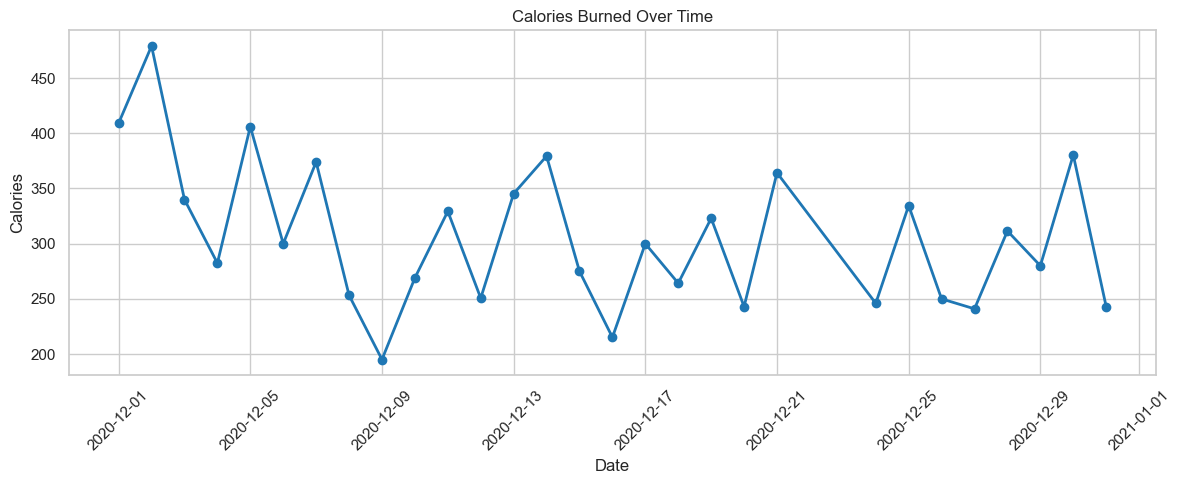

In [38]:
plt.figure(figsize=(12, 5))
plt.plot(
    clean_df["date"],
    clean_df["calories"],
    marker="o",
    linewidth=2,
    color="tab:blue"
)
plt.title("Calories Burned Over Time")
plt.xlabel("Date")
plt.ylabel("Calories")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

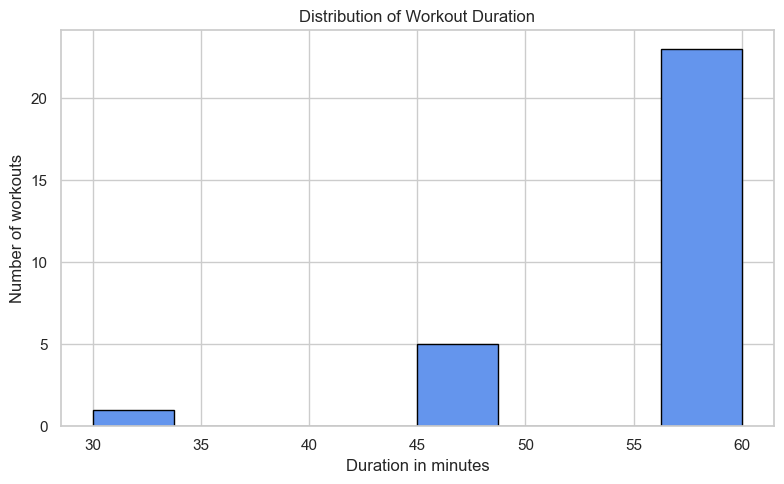

In [39]:
plt.figure(figsize=(8, 5))
plt.hist(clean_df["duration"], bins=8, edgecolor="black", color="cornflowerblue")
plt.title("Distribution of Workout Duration")
plt.xlabel("Duration in minutes")
plt.ylabel("Number of workouts")
plt.tight_layout()
plt.show()

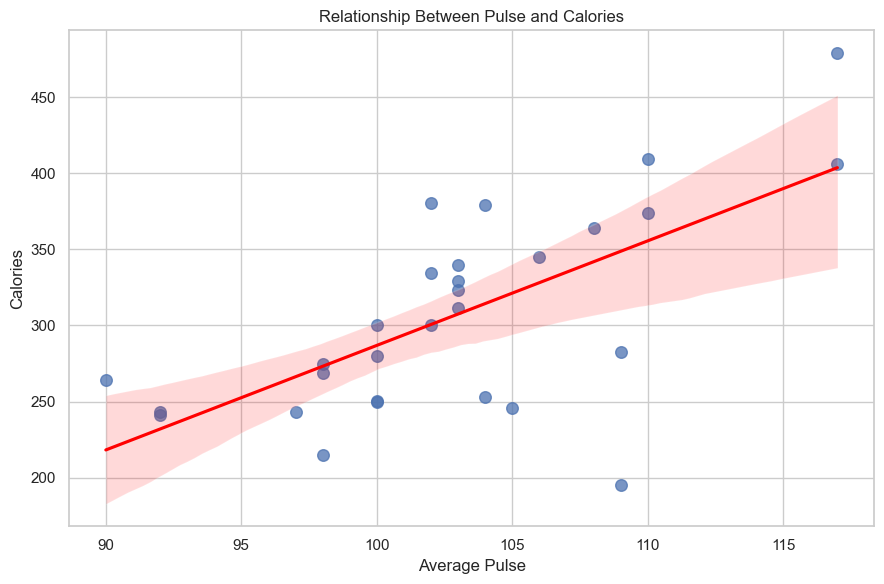

In [40]:
plt.figure(figsize=(9, 6))
sns.regplot(
    data=clean_df,
    x="pulse",
    y="calories",
    scatter_kws={"s": 70, "alpha": 0.75},
    line_kws={"color": "red"}
)
plt.title("Relationship Between Pulse and Calories")
plt.xlabel("Average Pulse")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()

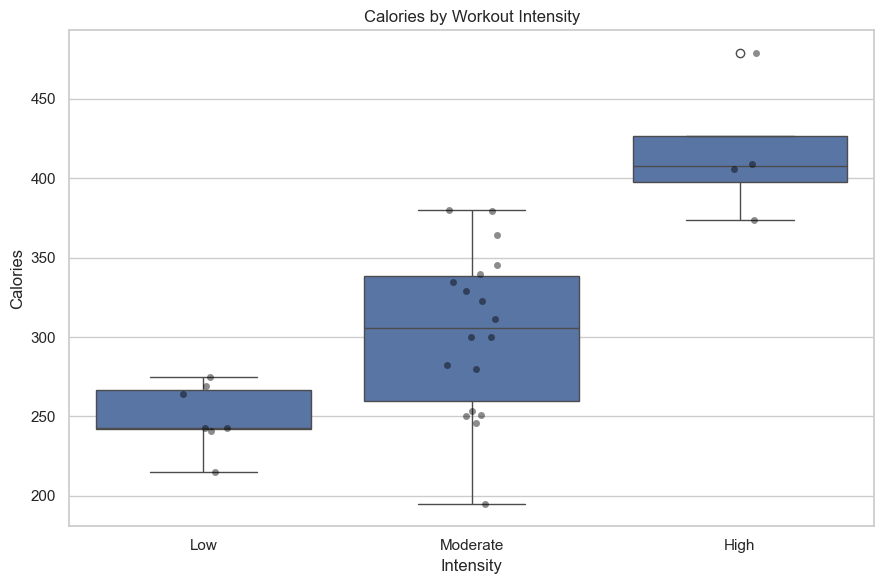

In [41]:
plt.figure(figsize=(9, 6))
sns.boxplot(
    data=clean_df,
    x="intensity",
    y="calories",
    order=["Low", "Moderate", "High"]
)
sns.stripplot(
    data=clean_df,
    x="intensity",
    y="calories",
    order=["Low", "Moderate", "High"],
    color="black",
    alpha=0.45
)
plt.title("Calories by Workout Intensity")
plt.xlabel("Intensity")
plt.ylabel("Calories")
plt.tight_layout()
plt.show()

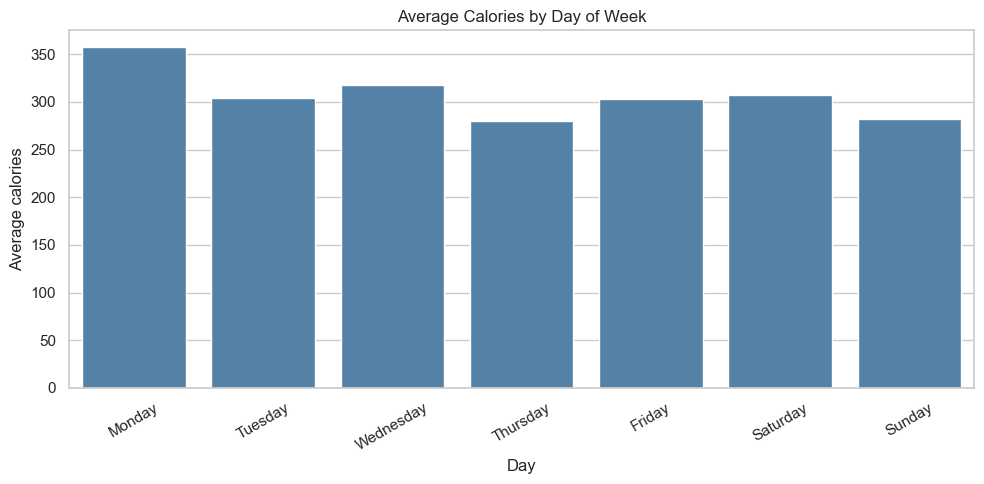

In [42]:
ordered_days = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
day_plot = (
    clean_df.groupby("day_name", as_index=False)["calories"]
    .mean()
    .rename(columns={"calories": "average_calories"})
)
day_plot["day_name"] = pd.Categorical(
    day_plot["day_name"], categories=ordered_days, ordered=True
)
day_plot = day_plot.sort_values("day_name")

plt.figure(figsize=(10, 5))
sns.barplot(data=day_plot, x="day_name", y="average_calories", color="steelblue")
plt.title("Average Calories by Day of Week")
plt.xlabel("Day")
plt.ylabel("Average calories")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [43]:
analysis_columns = [
    "duration",
    "pulse",
    "maxpulse",
    "calories",
    "calories_per_minute",
    "pulse_gap"
]

correlation_matrix = clean_df[analysis_columns].corr().round(2)
correlation_matrix

,duration,pulse,maxpulse,calories,calories_per_minute,pulse_gap
duration,1.00,-0.18,-0.27,0.33,-0.38,-0.24
pulse,-0.18,1.00,0.71,0.66,0.79,0.25
maxpulse,-0.27,0.71,1.00,0.38,0.57,0.86
calories,0.33,0.66,0.38,1.00,0.74,0.05
calories_per_minute,-0.38,0.79,0.57,0.74,1.00,0.21
pulse_gap,-0.24,0.25,0.86,0.05,0.21,1.00


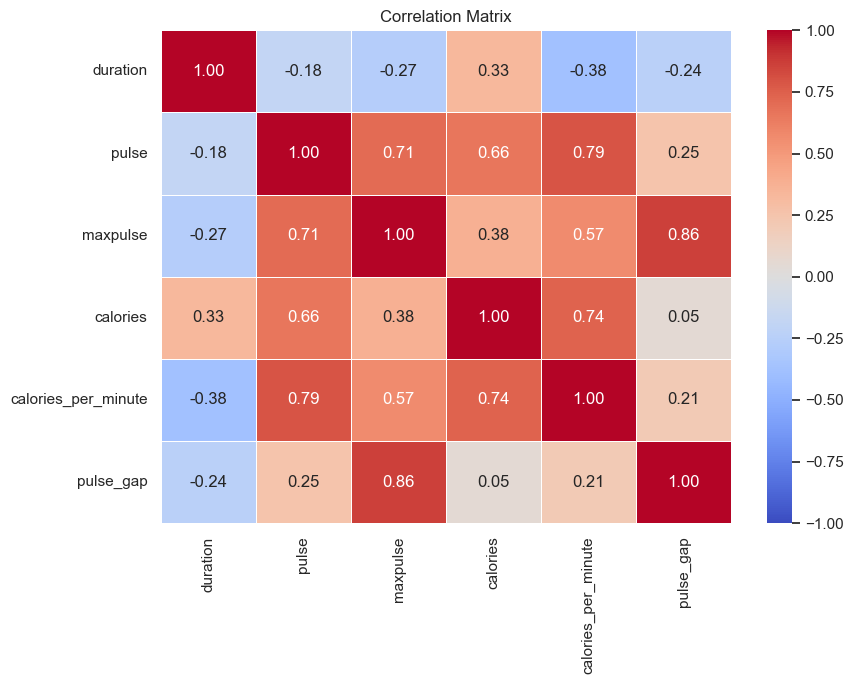

In [44]:
plt.figure(figsize=(9, 7))
sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    fmt=".2f",
    linewidths=0.5
)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [45]:
highest_calorie = clean_df.loc[clean_df["calories"].idxmax()]
highest_efficiency = clean_df.loc[clean_df["calories_per_minute"].idxmax()]

findings = {
    "cleaned_rows": len(clean_df),
    "date_range": f"{clean_df['date'].min().date()} to {clean_df['date'].max().date()}",
    "average_duration_minutes": round(clean_df["duration"].mean(), 2),
    "average_pulse": round(clean_df["pulse"].mean(), 2),
    "average_calories": round(clean_df["calories"].mean(), 2),
    "highest_calorie_date": str(highest_calorie["date"].date()),
    "highest_calorie_value": round(float(highest_calorie["calories"]), 2),
    "most_efficient_date": str(highest_efficiency["date"].date()),
    "most_efficient_calories_per_minute": round(float(highest_efficiency["calories_per_minute"]), 2)
}

findings

{'cleaned_rows': 29,
 'date_range': '2020-12-01 to 2020-12-31',
 'average_duration_minutes': 56.38,
 'average_pulse': 102.83,
 'average_calories': 306.32,
 'highest_calorie_date': '2020-12-02',
 'highest_calorie_value': 479.0,
 'most_efficient_date': '2020-12-05',
 'most_efficient_calories_per_minute': 9.02}

In [46]:
cleaned_file = Path("cleaned_workout_data.csv")
clean_df.to_csv(cleaned_file, index=False)
print(f"Saved cleaned data to: {cleaned_file.resolve()}")

Saved cleaned data to: C:\Users\amans\cleaned_workout_data.csv
